In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('IMDB Dataset.csv')

In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
49995,False
49996,False
49997,False
49998,False


In [ ]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [ ]:
df.duplicated().sum()

np.int64(418)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
print("New Shape:", df.shape)


New Shape: (49582, 2)


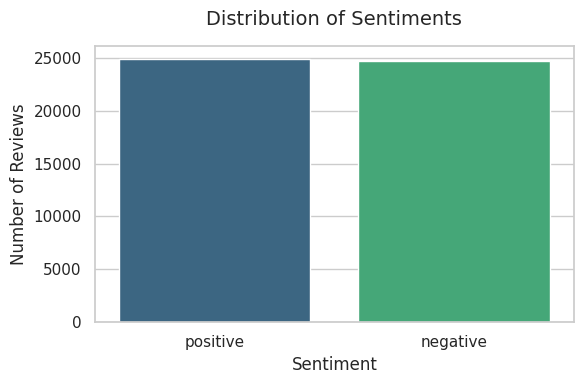

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for the plots
sns.set_theme(style="whitegrid")

# Create the count plot
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, hue='sentiment', palette='viridis', legend=False, ax=ax)

ax.set_title('Distribution of Sentiments', fontsize=14, pad=15)
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)

# Adjust layout to prevent truncation
plt.tight_layout()

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
import re

def clean_text_pipeline(text):
    # Convert to lowercase
    text = text.lower()

    # 1. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove HTML tags (like <br />)
    text = re.sub(r'<[^>]*>', '', text)

    # 2. Remove Numbers and Special Characters (keeps only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    return text

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Initialize Lemmatizer and Stop Words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def process_words_and_tokenize(text):
    cleaned_words = []

    # Split text into words to handle stop words and lemmatization
    for word in text.split():
        # 3. Remove Stop Words
        if word not in stop_words:
            # 4. Lemmatization (reduce to base form)
            lemma_word = lemmatizer.lemmatize(word)
            cleaned_words.append(lemma_word)

    # Reconstruct the cleaned string
    cleaned_sentence = " ".join(cleaned_words)

    # 5. Final Step: Tokenization
    final_tokens = word_tokenize(cleaned_sentence)

    return final_tokens

In [ ]:
# Apply the initial cleaning
df['cleaned_text'] = df['review'].apply(clean_text_pipeline)

# Apply stop words removal, lemmatization, and final tokenization
df['final_tokens'] = df['cleaned_text'].apply(process_words_and_tokenize)

# Drop the temporary column to keep things neat
df.drop(columns=['cleaned_text'], inplace=True)

# View the final output
df[['review', 'final_tokens']].head()

,review,final_tokens
0,One of the other reviewers has mentioned that ...,"[one, reviewer, mentioned, watching, oz, episo..."
1,A wonderful little production. <br /><br />The...,"[wonderful, little, production, filming, techn..."
2,I thought this was a wonderful way to spend ti...,"[thought, wonderful, way, spend, time, hot, su..."
3,Basically there's a family where a little boy ...,"[basically, there, family, little, boy, jake, ..."
4,"Petter Mattei's ""Love in the Time of Money"" is...","[petter, matteis, love, time, money, visually,..."


In [22]:
from sklearn.model_selection import train_test_split

# 1. Convert the final_tokens list back into a string for vectorization
df['processed_review'] = df['final_tokens'].apply(lambda tokens: ' '.join(tokens))

# 2. Define Features (X) and Target (y)
X = df['processed_review']
y = df['sentiment']

# 3. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. Verify the splits
print(f"Training set size: {X_train.shape[0]} reviews")
print(f"Testing set size: {X_test.shape[0]} reviews")

Training set size: 39665 reviews
Testing set size: 9917 reviews


# Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # You can adjust max_features as needed

# Fit on training data and transform both training and test data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("=== Training Logistic Regression ===")
# Initialize and train
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# Predict and evaluate
y_pred_lr = lr_model.predict(X_test_tfidf)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

=== Training Logistic Regression ===
Logistic Regression Accuracy: 0.8819
              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      4940
    positive       0.87      0.89      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



# Naive Bayes

In [25]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

print("=== Training Naive Bayes ===")
# Initialize and train
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predict and evaluate
y_pred_nb = nb_model.predict(X_test_tfidf)
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(classification_report(y_test, y_pred_nb))

=== Training Naive Bayes ===
Naive Bayes Accuracy: 0.8509
              precision    recall  f1-score   support

    negative       0.85      0.84      0.85      4940
    positive       0.85      0.86      0.85      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



# Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("=== Training Random Forest ===")
# Initialize and train (max_depth limits tree depth to keep execution fast)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test_tfidf)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

=== Training Random Forest ===
Random Forest Accuracy: 0.8270
              precision    recall  f1-score   support

    negative       0.86      0.78      0.82      4940
    positive       0.80      0.88      0.84      4977

    accuracy                           0.83      9917
   macro avg       0.83      0.83      0.83      9917
weighted avg       0.83      0.83      0.83      9917



### Confusion Matrix Visualization

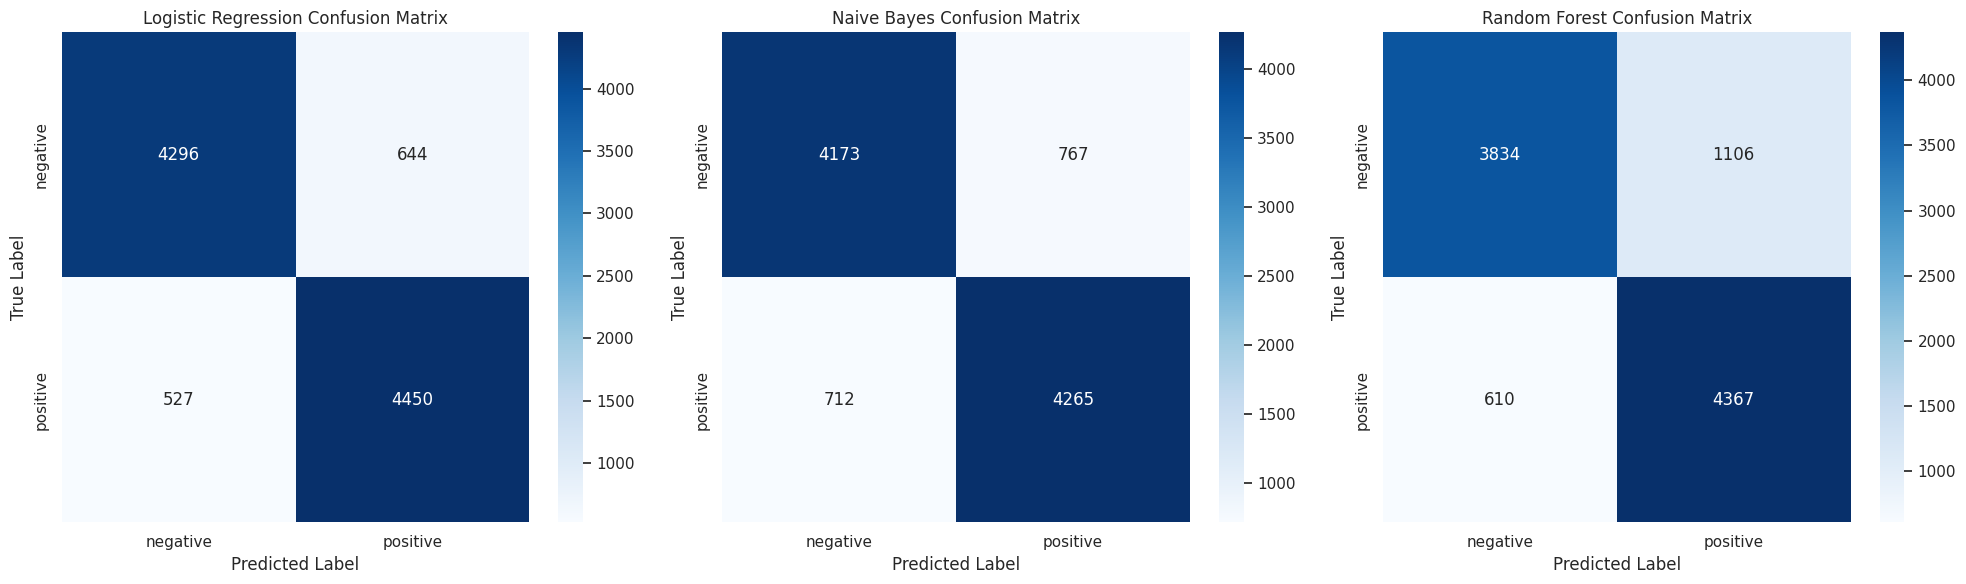

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['negative', 'positive'],
                yticklabels=['negative', 'positive'])
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Logistic Regression Confusion Matrix
plot_confusion_matrix(y_test, y_pred_lr, 'Logistic Regression Confusion Matrix', axes[0])

# Naive Bayes Confusion Matrix
plot_confusion_matrix(y_test, y_pred_nb, 'Naive Bayes Confusion Matrix', axes[1])

# Random Forest Confusion Matrix
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest Confusion Matrix', axes[2])

plt.tight_layout()
plt.show()

# Hyperparameter Tuning for Logistic Regression

In [31]:
from sklearn.model_selection import GridSearchCV

print("=== Tuning Logistic Regression ===")
# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.1, 1, 10, 100], # Inverse of regularization strength
    'penalty': ['l2'] # L2 penalty (ridge regularization) is common for Logistic Regression
}

# Initialize GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid_lr,
    cv=5, # Cross-validation folds
    scoring='accuracy',
    n_jobs=-1, # Use all available cores
    verbose=1 # Show progress
)

# Fit GridSearchCV to the training data
grid_search_lr.fit(X_train_tfidf, y_train)

# Get the best parameters and best score
best_params_lr = grid_search_lr.best_params_
best_score_lr = grid_search_lr.best_score_

print(f"Best Parameters for Logistic Regression: {best_params_lr}")
print(f"Best Cross-Validation Accuracy for Logistic Regression: {best_score_lr:.4f}")

# Evaluate the tuned Logistic Regression model on the test set
best_lr_model = grid_search_lr.best_estimator_
y_pred_lr_tuned = best_lr_model.predict(X_test_tfidf)

print(f"Tuned Logistic Regression Test Accuracy: {accuracy_score(y_test, y_pred_lr_tuned):.4f}")
print(classification_report(y_test, y_pred_lr_tuned))

=== Tuning Logistic Regression ===
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters for Logistic Regression: {'C': 1, 'penalty': 'l2'}
Best Cross-Validation Accuracy for Logistic Regression: 0.8841
Tuned Logistic Regression Test Accuracy: 0.8819
              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      4940
    positive       0.87      0.89      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



### Save the Tuned Logistic Regression Model

In [32]:
import joblib

# Define the filename for the pickle file
model_filename = 'tuned_logistic_regression_model.pkl'

# Save the best Logistic Regression model to a pickle file
joblib.dump(best_lr_model, model_filename)

print(f"Tuned Logistic Regression model saved successfully to {model_filename}")

Tuned Logistic Regression model saved successfully to tuned_logistic_regression_model.pkl
